# AELTC — Scenario 1: Ticket Holder Arrival Pattern Analysis

**Platform:** IBM watsonx.data Intelligence + Confluent Tableflow (Iceberg) + IBM Data Product Hub  
**Analyst persona:** AELTC Data Analyst  
**Business question:** *What factors influence when different types of ticket holders arrive on site during The Championships?*

---

## Datasets used

| Dataset | Source system | Ingest path | Sensitivity |
|---|---|---|---|
| `gate_scans` | Access control / turnstile system | Confluent topic → Iceberg table | Internal |
| `customer_profiles` | CIAM platform | Confluent topic → Iceberg table | **PII** — masked for non-stewards |
| `match_schedule` | Tournament Management System (TMS) | Confluent topic → Iceberg table | Public |
| `weather_observations` | Third-party weather API | Batch connector → Iceberg table | Public |

> **Governance note:** All datasets were discovered via the **watsonx.data Intelligence catalogue**.  
> `customer_profiles` PII columns (`email`, `full_name`) are dynamically masked at query time for the analyst role.  
> This notebook is published to the catalogue and the joined dataset is registered as a **Data Product** in IBM Data Product Hub.

---

## 0 · Environment Setup

In [1]:
# Install dependencies (run once — pre-installed in managed watsonx.data notebook environment)
import subprocess, sys

pkgs = [
    "pandas>=2.2",
    "numpy>=1.26",
    "scipy>=1.13",
    "matplotlib>=3.8",
    "seaborn>=0.13",
    "plotly>=5.22",
    "scikit-learn>=1.5",
    "statsmodels>=0.14",
]
for pkg in pkgs:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

print("Dependencies ready.")


[notice] A new release of pip is available: 25.1.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.1.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.1.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.1.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.1.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.1.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.1.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


Dependencies ready.



[notice] A new release of pip is available: 25.1.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


In [2]:
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from scipy import stats
import statsmodels.formula.api as smf

warnings.filterwarnings("ignore")

# ── Plot theme ─────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="deep", font_scale=1.05)
plt.rcParams.update({
    "figure.dpi": 120,
    "figure.facecolor": "white",
    "axes.spines.top": False,
    "axes.spines.right": False,
})

SEED = 42
rng  = np.random.default_rng(SEED)

# ── Championship parameters ────────────────────────────────────────
START_DATE         = pd.Timestamp("2025-06-30")
CHAMPIONSHIP_DAYS  = 14
DAILY_VISITORS     = 42_000

print("Environment ready.")

/Users/ganaibm/anaconda3/lib/python3.11/site-packages/pandas/core/computation/expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.4' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/Users/ganaibm/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.6' currently installed).
  from pandas.core import (


Environment ready.


---
## 1 · Data Discovery

In production the analyst opens the **watsonx.data Intelligence catalogue**, searches for `arrival`, `ticket`, `gate scan` and finds the four governed Iceberg tables below.  
Each table shows its quality score, lineage, business glossary terms and sensitivity labels *before* the analyst runs a single query.

Here we generate synthetic data whose schema and statistical properties match the real AELTC datasets.

In [3]:
# ── 1a. Match Schedule (from TMS via Confluent → Iceberg) ──────────
COURTS = [
    "Centre Court", "No.1 Court", "No.2 Court", "No.3 Court",
    "Court 4", "Court 5", "Court 6", "Court 7",
    "Court 8", "Court 12", "Court 18",
]

match_rows = []
for day_offset in range(CHAMPIONSHIP_DAYS):
    match_date = START_DATE + pd.Timedelta(days=day_offset)
    for court in COURTS:
        if court in ("Centre Court", "No.1 Court"):
            hour, minute = 13, int(rng.integers(0, 15))
        elif court in ("No.2 Court", "No.3 Court"):
            hour, minute = 12, int(rng.integers(0, 30))
        else:
            hour, minute = 11, int(rng.integers(0, 60))

        first_serve = match_date + pd.Timedelta(hours=hour, minutes=minute)
        rain_delay  = int(rng.integers(20, 120)) if (
            rng.random() < 0.15 and court not in ("Centre Court", "No.1 Court")
        ) else 0

        match_rows.append({
            "match_id"        : f"{match_date.strftime('%Y%m%d')}_{court.replace(' ', '')}",
            "match_date"      : match_date.date(),
            "court"           : court,
            "first_serve_time": first_serve,
            "rain_delay_mins" : rain_delay,
        })

match_schedule = pd.DataFrame(match_rows)
print(f"match_schedule : {len(match_schedule):,} rows")
match_schedule.head(4)

match_schedule : 154 rows


,match_id,match_date,court,first_serve_time,rain_delay_mins
0,20250630_CentreCourt,2025-06-30,Centre Court,2025-06-30 13:01:00,0
1,20250630_No.1Court,2025-06-30,No.1 Court,2025-06-30 13:11:00,0
2,20250630_No.2Court,2025-06-30,No.2 Court,2025-06-30 12:02:00,89
3,20250630_No.3Court,2025-06-30,No.3 Court,2025-06-30 12:15:00,0


In [4]:
# ── 1b. Weather Observations (third-party API → Iceberg) ───────────
weather_rows = []
for day_offset in range(CHAMPIONSHIP_DAYS):
    obs_date   = (START_DATE + pd.Timedelta(days=day_offset)).date()
    day_temp   = float(rng.normal(21.0, 3.5))
    is_rain    = rng.random() < 0.30
    for hour in range(8, 22):
        weather_rows.append({
            "observation_date" : obs_date,
            "hour"             : hour,
            "temperature_c"    : round(day_temp + float(rng.normal(0, 1.2)), 1),
            "precipitation_mm" : round(float(rng.exponential(2.5)), 2) if (is_rain and 11 <= hour <= 17) else 0.0,
            "is_rain_day"      : is_rain,
        })

weather = pd.DataFrame(weather_rows)
print(f"weather_observations : {len(weather):,} rows")
weather.head(3)

weather_observations : 196 rows


,observation_date,hour,temperature_c,precipitation_mm,is_rain_day
0,2025-06-30,8,15.9,0.0,False
1,2025-06-30,9,18.3,0.0,False
2,2025-06-30,10,17.2,0.0,False


In [5]:
# ── 1c. Customer Profiles (CIAM via Confluent → Iceberg, PII masked) ─
TICKET_TIERS = {
    "Centre Court Debenture": {"weight": 0.04, "intl_rate": 0.55, "early_bias": -40},
    "Centre Court"          : {"weight": 0.10, "intl_rate": 0.40, "early_bias": -25},
    "No.1 Court"            : {"weight": 0.12, "intl_rate": 0.38, "early_bias": -18},
    "No.2 Court"            : {"weight": 0.14, "intl_rate": 0.30, "early_bias": -10},
    "Grounds Pass"          : {"weight": 0.35, "intl_rate": 0.20, "early_bias":   5},
    "Queue Ticket"          : {"weight": 0.25, "intl_rate": 0.18, "early_bias":  20},
}
NATIONALITIES = {
    "UK": 0.52, "USA": 0.12, "Australia": 0.07, "Germany": 0.05,
    "France": 0.05, "Spain": 0.04, "Japan": 0.04,
    "Canada": 0.03, "Switzerland": 0.03, "Other": 0.05,
}
TIER_ORDINAL = {
    "Centre Court Debenture": 5, "Centre Court": 4, "No.1 Court": 3,
    "No.2 Court": 2, "Grounds Pass": 1, "Queue Ticket": 0,
}
TIER_ORDER = list(TICKET_TIERS.keys())

N = CHAMPIONSHIP_DAYS * DAILY_VISITORS
tier_names    = list(TICKET_TIERS)
tier_weights  = [TICKET_TIERS[t]["weight"] for t in tier_names]

chosen_tiers = rng.choice(tier_names, size=N, p=tier_weights)
chosen_nats  = rng.choice(list(NATIONALITIES), size=N, p=list(NATIONALITIES.values()))

customer_profiles = pd.DataFrame({
    "barcode_id"     : [f"BC{str(i).zfill(8)}" for i in range(N)],
    "ticket_tier"    : chosen_tiers,
    "nationality"    : chosen_nats,
    "is_international": (chosen_nats != "UK").astype(int),
    "registered_app" : rng.choice([True, False], size=N, p=[0.62, 0.38]),
    "full_name"      : "[MASKED]",   # PII — masked by watsonx.data policy
    "email"          : "[MASKED]",   # PII — masked by watsonx.data policy
})

print(f"customer_profiles : {len(customer_profiles):,} rows")
customer_profiles.head(3)

customer_profiles : 588,000 rows


,barcode_id,ticket_tier,nationality,is_international,registered_app,full_name,email
0,BC00000000,No.2 Court,UK,0,False,[MASKED],[MASKED]
1,BC00000001,Queue Ticket,UK,0,True,[MASKED],[MASKED]
2,BC00000002,Grounds Pass,UK,0,True,[MASKED],[MASKED]


In [6]:
# ── 1d. Gate Scans (access control system via Confluent → Iceberg) ──
COURT_WEIGHTS = [0.15, 0.13, 0.12, 0.10, 0.10, 0.08, 0.08, 0.07, 0.07, 0.05, 0.05]

scan_rows = []
for day_offset in range(CHAMPIONSHIP_DAYS):
    scan_date   = (START_DATE + pd.Timedelta(days=day_offset)).date()
    day_wx      = weather[weather["observation_date"] == scan_date]
    is_rain_day = bool(day_wx["is_rain_day"].iloc[0]) if len(day_wx) else False
    avg_temp    = float(day_wx["temperature_c"].mean()) if len(day_wx) else 21.0

    day_customers    = customer_profiles.sample(DAILY_VISITORS, replace=True,
                                                 random_state=SEED + day_offset)
    assigned_courts  = rng.choice(COURTS, size=DAILY_VISITORS, p=COURT_WEIGHTS)

    for i, (_, cust) in enumerate(day_customers.iterrows()):
        court = assigned_courts[i]
        sched = match_schedule[
            (match_schedule["match_date"] == scan_date) &
            (match_schedule["court"] == court)
        ]
        if sched.empty:
            continue

        first_serve  = sched.iloc[0]["first_serve_time"]
        rain_delay   = sched.iloc[0]["rain_delay_mins"]
        tier_bias    = TICKET_TIERS[cust["ticket_tier"]]["early_bias"]
        intl_bonus   = -18 if cust["is_international"] else 0
        rain_bonus   = 35  if is_rain_day else 0
        hot_bonus    = -12 if avg_temp > 24 else 0
        noise        = float(rng.normal(0, 22))

        mins_before  = float(np.clip(90 + tier_bias + intl_bonus + rain_bonus + hot_bonus + noise, 5, 240))
        scan_ts      = first_serve - pd.Timedelta(minutes=mins_before)

        scan_rows.append({
            "barcode_id"          : cust["barcode_id"],
            "scan_timestamp"      : scan_ts,
            "scan_date"           : scan_date,
            "gate_id"             : f"Gate_{rng.integers(1, 9)}",
            "court"               : court,
            "first_serve_time"    : first_serve,
            "minutes_before_serve": round(mins_before, 1),
            "rain_delay_mins"     : rain_delay,
        })

gate_scans = pd.DataFrame(scan_rows)
print(f"gate_scans : {len(gate_scans):,} rows")
gate_scans.head(3)

gate_scans : 588,000 rows


,barcode_id,scan_timestamp,scan_date,gate_id,court,first_serve_time,minutes_before_serve,rain_delay_mins
0,BC00121958,2025-06-30 09:54:47.549694325,2025-06-30,Gate_5,Court 4,2025-06-30 11:58:00,123.2,0
1,BC00131932,2025-06-30 09:25:54.399739032,2025-06-30,Gate_6,Court 18,2025-06-30 11:26:00,120.1,0
2,BC00365838,2025-06-30 11:49:18.830637905,2025-06-30,Gate_3,Centre Court,2025-06-30 13:01:00,71.7,0


---
## 2 · Data Preparation — Four-Way Join

In production this runs as a **Presto SQL query** directly against the Iceberg tables in watsonx.data.  
The equivalent SQL is shown for reference.

In [7]:
PRESTO_SQL = """
-- Production query — runs on watsonx.data Presto endpoint
SELECT
    g.scan_timestamp,
    g.scan_date,
    g.gate_id,
    g.court,
    g.first_serve_time,
    g.minutes_before_serve,
    g.rain_delay_mins,
    c.ticket_tier,
    c.nationality,
    c.is_international,
    c.registered_app,
    w.temperature_c,
    w.precipitation_mm,
    w.is_rain_day
FROM iceberg.aeltc_gold.gate_scans             g
JOIN iceberg.aeltc_gold.customer_profiles      c   ON  g.barcode_id   = c.barcode_id
JOIN iceberg.aeltc_gold.weather_observations   w   ON  g.scan_date    = w.observation_date
                                                   AND HOUR(g.scan_timestamp) = w.hour
WHERE g.scan_date BETWEEN DATE '2025-06-30' AND DATE '2025-07-13'
"""
print(PRESTO_SQL)

# ── Pandas equivalent (runs here on synthetic data) ─────────────────
df = gate_scans.merge(
    customer_profiles[["barcode_id","ticket_tier","nationality","is_international","registered_app"]],
    on="barcode_id", how="left"
)
df["scan_hour"] = pd.to_datetime(df["scan_timestamp"]).dt.hour
df = df.merge(
    weather,
    left_on=["scan_date", "scan_hour"],
    right_on=["observation_date", "hour"],
    how="left"
)

# Derived features
df["temp_band"] = pd.cut(
    df["temperature_c"],
    bins=[0, 15, 19, 23, 40],
    labels=["Cold (<15°C)","Cool (15–19°C)","Warm (19–23°C)","Hot (>23°C)"]
)
df["tier_group"] = df["ticket_tier"].map({
    "Centre Court Debenture":"Premium","Centre Court":"Premium",
    "No.1 Court":"Reserved","No.2 Court":"Reserved",
    "Grounds Pass":"General","Queue Ticket":"General",
})
df["tier_ordinal"] = df["ticket_tier"].map(TIER_ORDINAL)
df["day_number"]  = (pd.to_datetime(df["scan_date"]) - START_DATE).dt.days + 1
df["is_rain_day"] = df["is_rain_day"].fillna(False)

print(f"Joined dataset : {len(df):,} rows × {df.shape[1]} columns")


-- Production query — runs on watsonx.data Presto endpoint
SELECT
    g.scan_timestamp,
    g.scan_date,
    g.gate_id,
    g.court,
    g.first_serve_time,
    g.minutes_before_serve,
    g.rain_delay_mins,
    c.ticket_tier,
    c.nationality,
    c.is_international,
    c.registered_app,
    w.temperature_c,
    w.precipitation_mm,
    w.is_rain_day
FROM iceberg.aeltc_gold.gate_scans             g
JOIN iceberg.aeltc_gold.customer_profiles      c   ON  g.barcode_id   = c.barcode_id
JOIN iceberg.aeltc_gold.weather_observations   w   ON  g.scan_date    = w.observation_date
                                                   AND HOUR(g.scan_timestamp) = w.hour
WHERE g.scan_date BETWEEN DATE '2025-06-30' AND DATE '2025-07-13'

Joined dataset : 588,000 rows × 22 columns


---
## 3 · Data Quality Check

Mirrors the quality rules defined in watsonx.data Intelligence before publishing the Data Product.

In [8]:
quality_rules = {
    "scan_timestamp completeness"   : df["scan_timestamp"].notna().mean(),
    "ticket_tier completeness"      : df["ticket_tier"].notna().mean(),
    "nationality completeness"      : df["nationality"].notna().mean(),
    "temperature_c completeness"    : df["temperature_c"].notna().mean(),
    "minutes_before_serve validity" : df["minutes_before_serve"].between(0, 300).mean(),
    "barcode_id daily uniqueness"   : 1 - df.duplicated(["barcode_id","scan_date"]).mean(),
}

qdf = pd.DataFrame([
    {"Rule": k, "Pass Rate": f"{v:.1%}",
     "Status": "✅ PASS" if v >= 0.95 else "⚠️  REVIEW"}
    for k, v in quality_rules.items()
])
overall_quality = np.mean(list(quality_rules.values()))

print(f"Overall Data Quality Score : {overall_quality:.1%}\n")
print(qdf.to_string(index=False))

Overall Data Quality Score : 99.4%

                         Rule Pass Rate Status
  scan_timestamp completeness    100.0% ✅ PASS
     ticket_tier completeness    100.0% ✅ PASS
     nationality completeness    100.0% ✅ PASS
   temperature_c completeness    100.0% ✅ PASS
minutes_before_serve validity    100.0% ✅ PASS
  barcode_id daily uniqueness     96.5% ✅ PASS


---
## 4 · Exploratory Analysis

### 4.1 Overall Arrival Distribution and Gate Load Heatmap

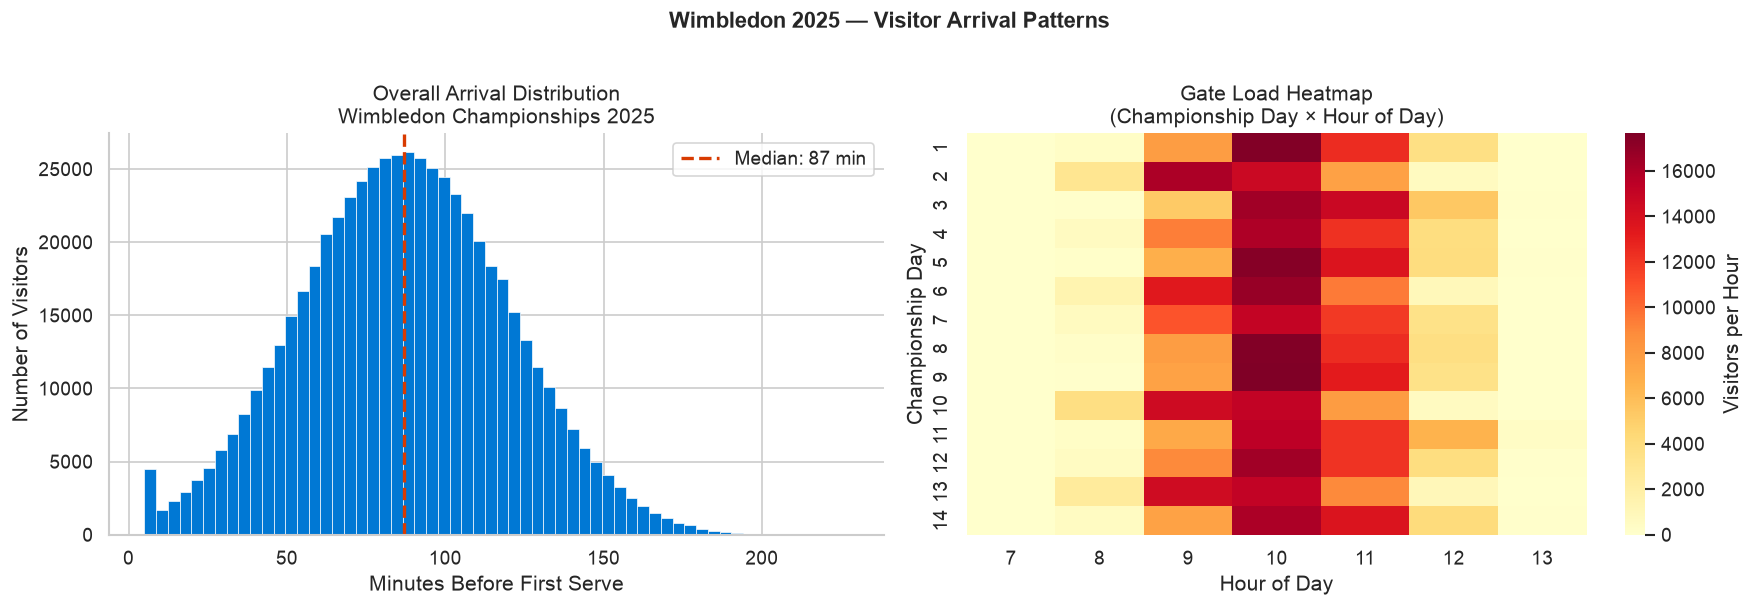

Median arrival  : 87 min before first serve
Peak gate hour  : 10:00


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Histogram
axes[0].hist(df["minutes_before_serve"], bins=60,
             color="#0078D4", edgecolor="white", linewidth=0.4)
median_val = df["minutes_before_serve"].median()
axes[0].axvline(median_val, color="#D83B01", lw=2, linestyle="--",
                label=f"Median: {median_val:.0f} min")
axes[0].set_xlabel("Minutes Before First Serve")
axes[0].set_ylabel("Number of Visitors")
axes[0].set_title("Overall Arrival Distribution\nWimbledon Championships 2025")
axes[0].legend()

# Gate load heatmap (day × hour)
heatmap_data = (df.groupby(["day_number","scan_hour"]).size()
                  .unstack(fill_value=0))
sns.heatmap(heatmap_data, ax=axes[1], cmap="YlOrRd",
            cbar_kws={"label":"Visitors per Hour"})
axes[1].set_title("Gate Load Heatmap\n(Championship Day × Hour of Day)")
axes[1].set_xlabel("Hour of Day")
axes[1].set_ylabel("Championship Day")

plt.suptitle("Wimbledon 2025 — Visitor Arrival Patterns",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("01_overall_arrival.png", bbox_inches="tight", dpi=150)
plt.show()
print(f"Median arrival  : {median_val:.0f} min before first serve")
print(f"Peak gate hour  : {int(df['scan_hour'].mode().iloc[0]):02d}:00")

### 4.2 Hypothesis 1 — Does Ticket Tier Predict Arrival Time?

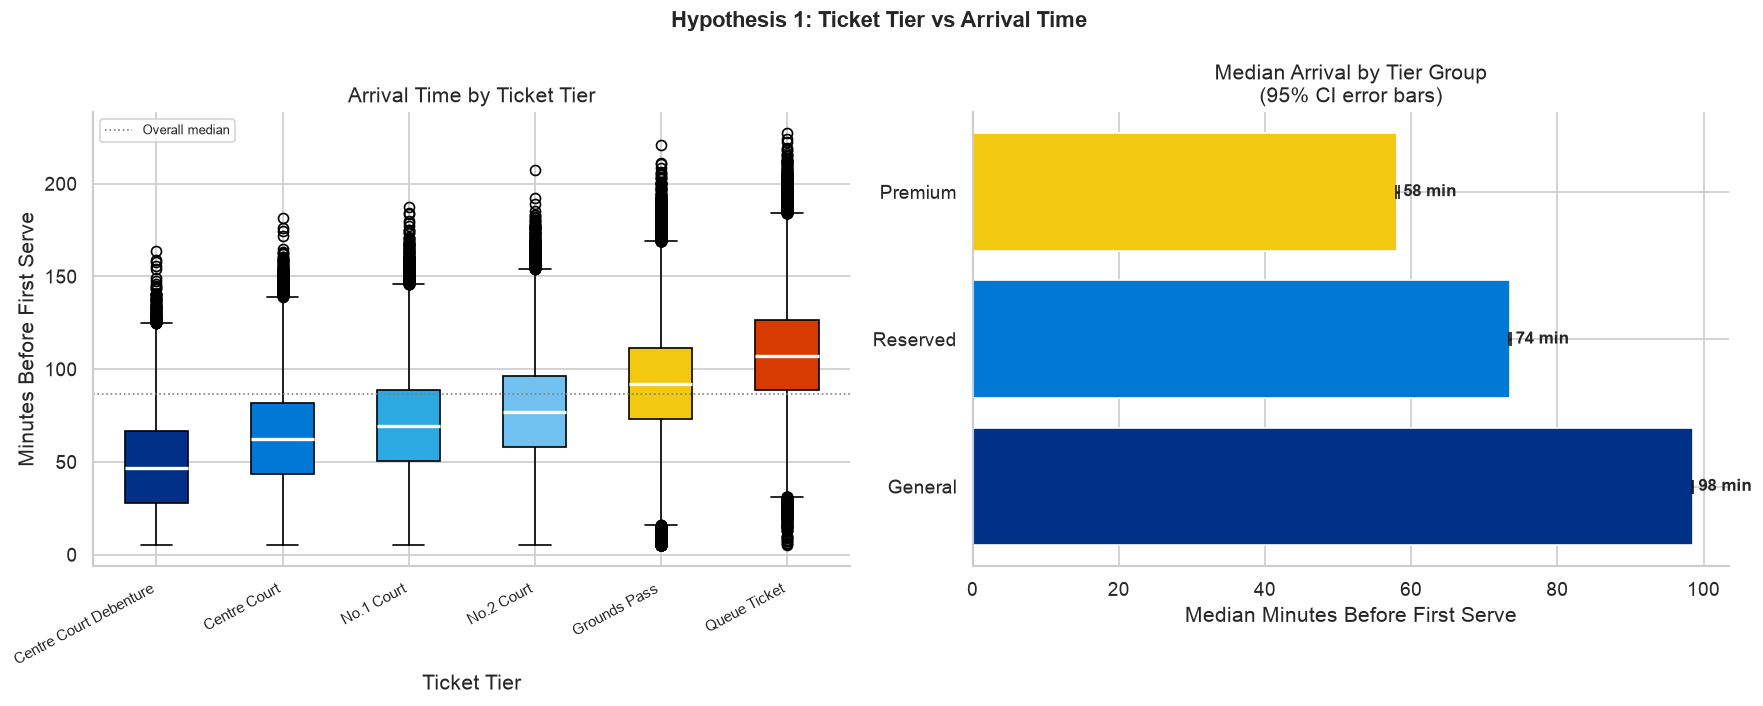

One-way ANOVA : F = 42674.2,  p = 0.00e+00
Ticket tier IS a statistically significant predictor (p < 0.001).


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

TIER_PALETTE = ["#003087","#0078D4","#2EA8E0","#70C1F0","#F2C811","#D83B01"]
tier_df = df.copy()
tier_df["ticket_tier"] = pd.Categorical(
    tier_df["ticket_tier"], categories=TIER_ORDER, ordered=True)

# Use matplotlib boxplot directly to avoid seaborn 0.13 palette bug
tier_groups = [tier_df[tier_df["ticket_tier"]==t]["minutes_before_serve"].dropna().values
               for t in TIER_ORDER]
bp = axes[0].boxplot(tier_groups, patch_artist=True, medianprops=dict(color='white', lw=2))
for patch, colour in zip(bp['boxes'], TIER_PALETTE):
    patch.set_facecolor(colour)
axes[0].set_xticks(range(1, len(TIER_ORDER)+1))
axes[0].axhline(df["minutes_before_serve"].median(), color="grey",
                lw=1, linestyle=":", label="Overall median")
axes[0].set_xticklabels(TIER_ORDER, rotation=28, ha="right", fontsize=9)
axes[0].set_xlabel("Ticket Tier")
axes[0].set_ylabel("Minutes Before First Serve")
axes[0].set_title("Arrival Time by Ticket Tier")
axes[0].legend(fontsize=8)

summary = (
    df.groupby("tier_group")["minutes_before_serve"]
      .agg(["median","std","count"]).reset_index()
      .sort_values("median", ascending=False)
)
summary["ci95"] = 1.96 * summary["std"] / np.sqrt(summary["count"])
bars = axes[1].barh(summary["tier_group"], summary["median"],
                    xerr=summary["ci95"],
                    color=["#003087","#0078D4","#F2C811"],
                    edgecolor="white", capsize=4)
for bar, val in zip(bars, summary["median"]):
    axes[1].text(val + 0.8, bar.get_y() + bar.get_height() / 2,
                 f"{val:.0f} min", va="center", fontsize=10, fontweight="bold")
axes[1].set_xlabel("Median Minutes Before First Serve")
axes[1].set_title("Median Arrival by Tier Group\n(95% CI error bars)")

plt.suptitle("Hypothesis 1: Ticket Tier vs Arrival Time",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("02_ticket_tier_arrival.png", bbox_inches="tight", dpi=150)
plt.show()

groups  = [g["minutes_before_serve"].values
           for _, g in df.groupby("ticket_tier")]
f_stat, p_val = stats.f_oneway(*groups)
print(f"One-way ANOVA : F = {f_stat:.1f},  p = {p_val:.2e}")
print("Ticket tier IS a statistically significant predictor (p < 0.001)." if p_val < 0.001
      else "No significant difference between tiers.")

### 4.3 Hypothesis 2 — Do International Visitors Arrive Earlier?

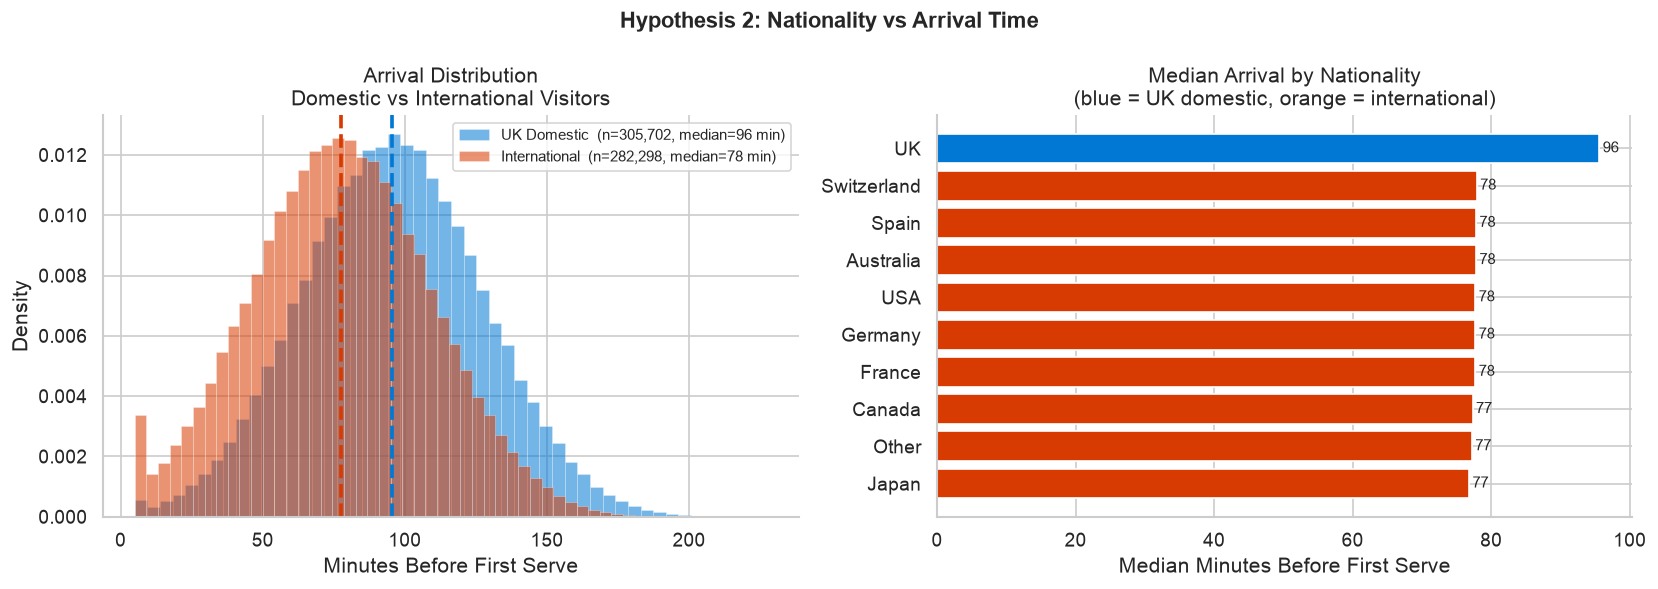

Welch t-test : t = 217.8,  p = 0.00e+00
International visitors arrive 18 min earlier than UK domestic.


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for flag, label, colour in [(0,"UK Domestic","#0078D4"),(1,"International","#D83B01")]:
    sub = df[df["is_international"] == flag]["minutes_before_serve"]
    axes[0].hist(sub, bins=50, alpha=0.55, density=True,
                 label=f"{label}  (n={len(sub):,}, median={sub.median():.0f} min)",
                 color=colour, edgecolor="white", linewidth=0.3)
    axes[0].axvline(sub.median(), color=colour, lw=2.2, linestyle="--")

axes[0].set_xlabel("Minutes Before First Serve")
axes[0].set_ylabel("Density")
axes[0].set_title("Arrival Distribution\nDomestic vs International Visitors")
axes[0].legend(fontsize=9)

nat_med = (
    df.groupby("nationality")["minutes_before_serve"]
      .median().sort_values(ascending=True)
)
colours_nat = ["#D83B01" if n != "UK" else "#0078D4" for n in nat_med.index]
axes[1].barh(nat_med.index, nat_med.values, color=colours_nat, edgecolor="white")
for i, (nat, val) in enumerate(nat_med.items()):
    axes[1].text(val + 0.5, i, f"{val:.0f}", va="center", fontsize=9)
axes[1].set_xlabel("Median Minutes Before First Serve")
axes[1].set_title("Median Arrival by Nationality\n(blue = UK domestic, orange = international)")

plt.suptitle("Hypothesis 2: Nationality vs Arrival Time",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("03_nationality_arrival.png", bbox_inches="tight", dpi=150)
plt.show()

uk_arr   = df[df["is_international"] == 0]["minutes_before_serve"]
intl_arr = df[df["is_international"] == 1]["minutes_before_serve"]
t_stat, t_pval = stats.ttest_ind(uk_arr, intl_arr, equal_var=False)
diff = intl_arr.median() - uk_arr.median()
print(f"Welch t-test : t = {t_stat:.1f},  p = {t_pval:.2e}")
print(f"International visitors arrive {abs(diff):.0f} min "
      f"{'earlier' if diff < 0 else 'later'} than UK domestic.")

### 4.4 Hypothesis 3 — Does Weather Affect Arrival Timing?

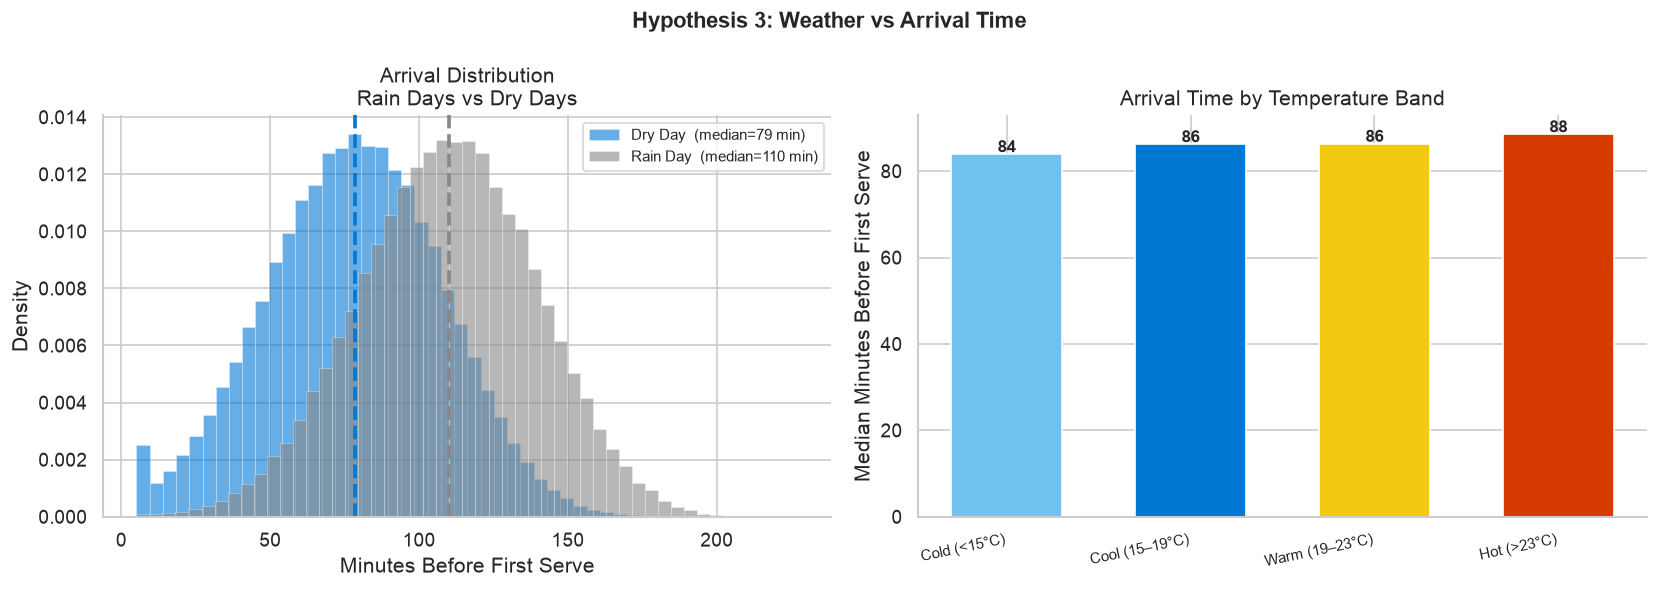

Welch t-test (rain vs dry) : t = -365.8,  p = 0.00e+00
Rain days shift arrivals 31 min later.


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for flag, label, colour in [(False,"Dry Day","#0078D4"),(True,"Rain Day","#888888")]:
    sub = df[df["is_rain_day"] == flag]["minutes_before_serve"]
    axes[0].hist(sub, bins=50, alpha=0.60, density=True,
                 label=f"{label}  (median={sub.median():.0f} min)",
                 color=colour, edgecolor="white", linewidth=0.3)
    axes[0].axvline(sub.median(), color=colour, lw=2.2, linestyle="--")

axes[0].set_xlabel("Minutes Before First Serve")
axes[0].set_ylabel("Density")
axes[0].set_title("Arrival Distribution\nRain Days vs Dry Days")
axes[0].legend(fontsize=9)

temp_sum = (
    df.groupby("temp_band", observed=True)["minutes_before_serve"]
      .median().reset_index()
)
bar_colours = ["#70C1F0","#0078D4","#F2C811","#D83B01"]
bars = axes[1].bar(range(len(temp_sum)), temp_sum["minutes_before_serve"],
                   color=bar_colours, edgecolor="white", width=0.6)
for i, val in enumerate(temp_sum["minutes_before_serve"]):
    axes[1].text(i, val + 0.5, f"{val:.0f}", ha="center",
                 fontsize=10, fontweight="bold")
axes[1].set_xticks(range(len(temp_sum)))
axes[1].set_xticklabels(temp_sum["temp_band"], rotation=12, ha="right", fontsize=9)
axes[1].set_ylabel("Median Minutes Before First Serve")
axes[1].set_title("Arrival Time by Temperature Band")

plt.suptitle("Hypothesis 3: Weather vs Arrival Time",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("04_weather_arrival.png", bbox_inches="tight", dpi=150)
plt.show()

dry_arr  = df[df["is_rain_day"] == False]["minutes_before_serve"]
rain_arr = df[df["is_rain_day"] == True]["minutes_before_serve"]
t2, p2   = stats.ttest_ind(dry_arr, rain_arr, equal_var=False)
print(f"Welch t-test (rain vs dry) : t = {t2:.1f},  p = {p2:.2e}")
print(f"Rain days shift arrivals {abs(rain_arr.median() - dry_arr.median()):.0f} min later.")

---
## 5 · Correlation Analysis — All Factors Together

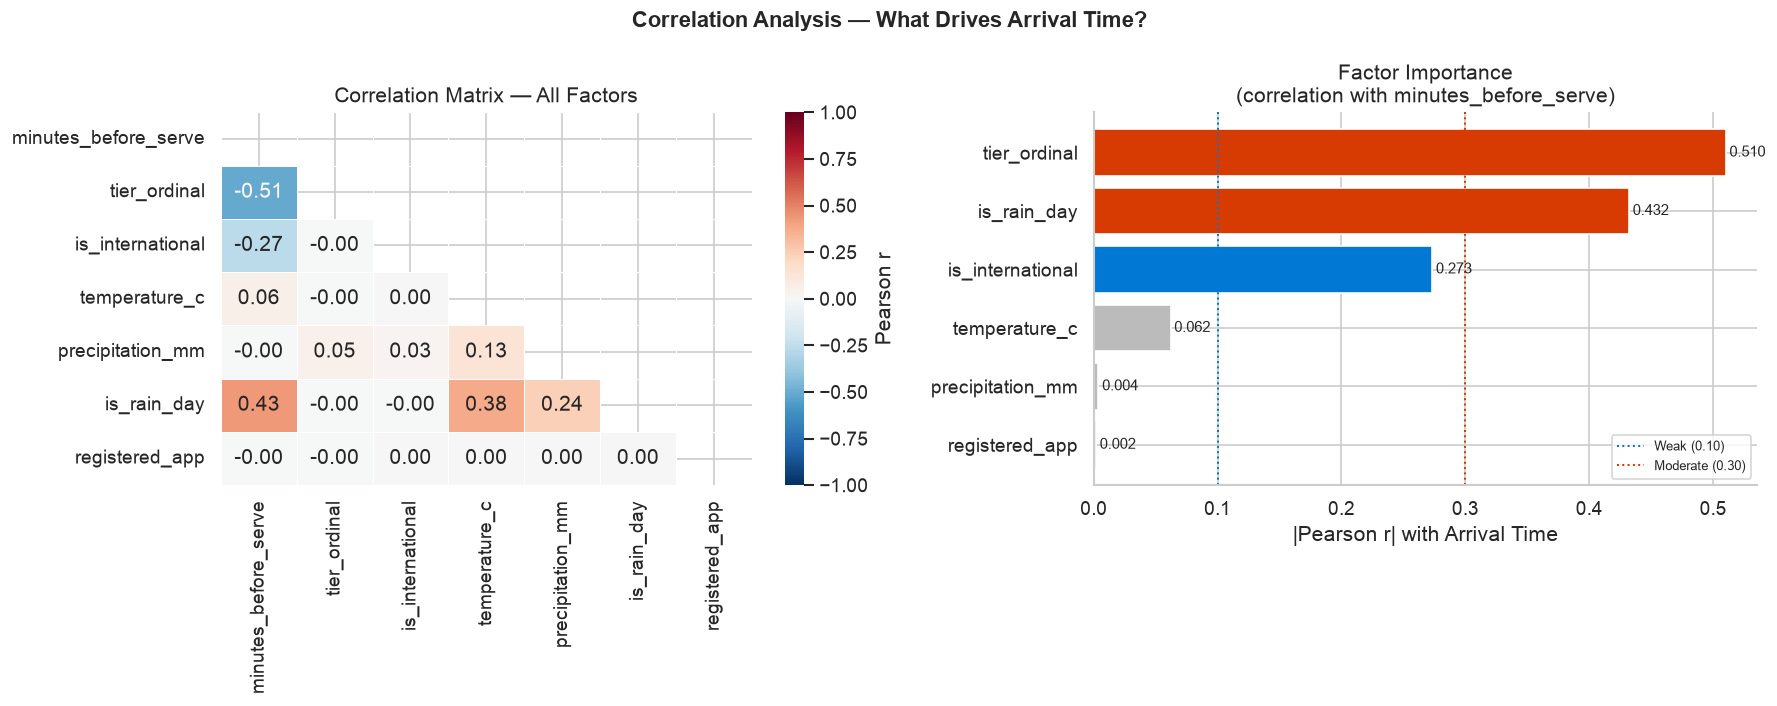

In [13]:
corr_df = df[[
    "minutes_before_serve","tier_ordinal","is_international",
    "temperature_c","precipitation_mm","is_rain_day","registered_app"
]].copy()
corr_df["is_rain_day"]    = corr_df["is_rain_day"].astype(int)
corr_df["registered_app"] = corr_df["registered_app"].astype(int)
corr_mat = corr_df.corr()

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

mask = np.triu(np.ones_like(corr_mat, dtype=bool))
sns.heatmap(corr_mat, mask=mask, ax=axes[0],
            cmap="RdBu_r", vmin=-1, vmax=1, center=0,
            annot=True, fmt=".2f", linewidths=0.5,
            cbar_kws={"label":"Pearson r"})
axes[0].set_title("Correlation Matrix — All Factors")

target_corr = (
    corr_mat["minutes_before_serve"]
    .drop("minutes_before_serve").abs()
    .sort_values(ascending=True)
)
bar_c = ["#D83B01" if v > 0.3 else "#0078D4" if v > 0.1 else "#BBBBBB"
         for v in target_corr.values]
axes[1].barh(target_corr.index, target_corr.values,
             color=bar_c, edgecolor="white")
axes[1].axvline(0.1, color="#0078D4", lw=1.2, linestyle=":",
                label="Weak (0.10)")
axes[1].axvline(0.3, color="#D83B01", lw=1.2, linestyle=":",
                label="Moderate (0.30)")
for feat, val in target_corr.items():
    axes[1].text(val + 0.003, list(target_corr.index).index(feat),
                 f"{val:.3f}", va="center", fontsize=9)
axes[1].set_xlabel("|Pearson r| with Arrival Time")
axes[1].set_title("Factor Importance\n(correlation with minutes_before_serve)")
axes[1].legend(fontsize=8)

plt.suptitle("Correlation Analysis — What Drives Arrival Time?",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("05_correlation.png", bbox_inches="tight", dpi=150)
plt.show()

---
## 6 · Multi-Factor Heatmaps — Tier × Weather Interaction

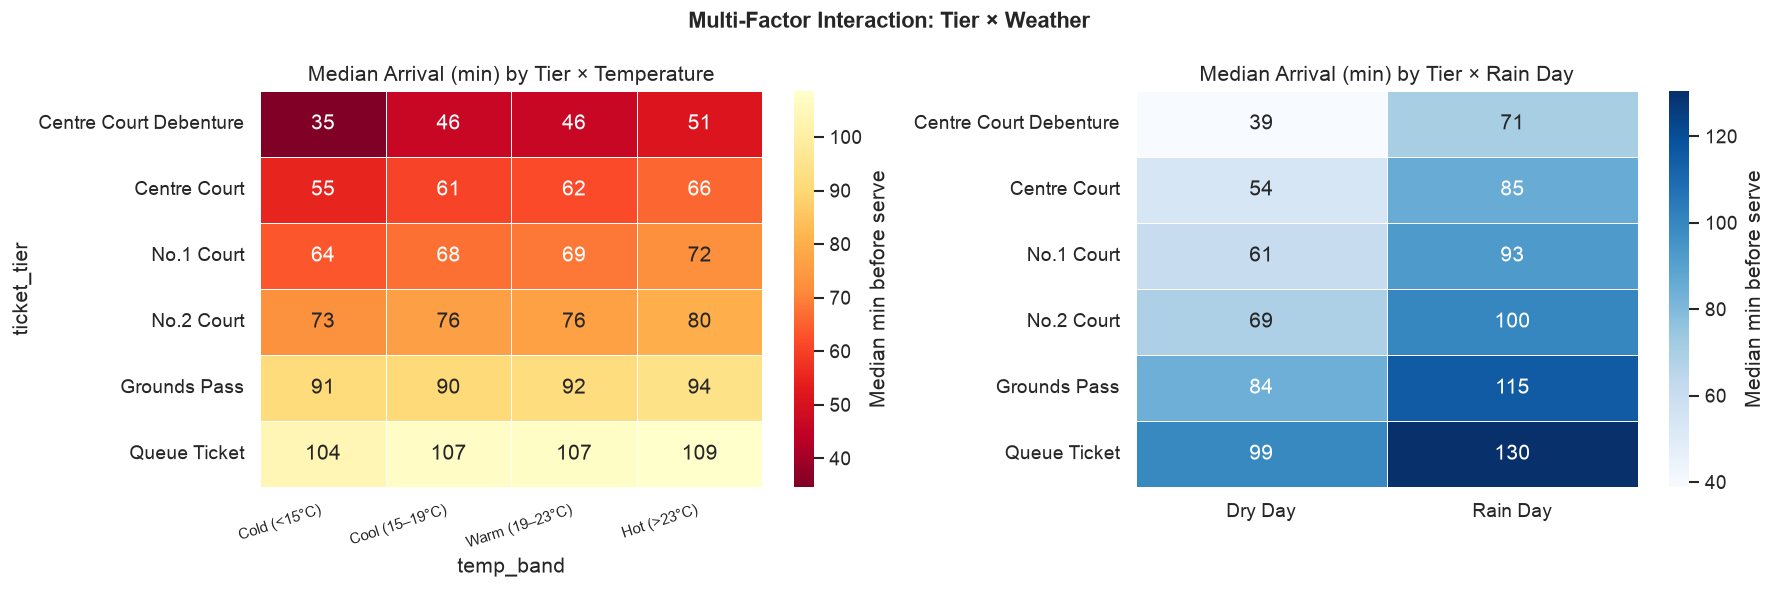

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

pivot_temp = (
    df.pivot_table(values="minutes_before_serve",
                   index="ticket_tier", columns="temp_band",
                   aggfunc="median", observed=True)
      .reindex(TIER_ORDER)
)
sns.heatmap(pivot_temp, ax=axes[0], cmap="YlOrRd_r",
            annot=True, fmt=".0f", linewidths=0.5,
            cbar_kws={"label":"Median min before serve"})
axes[0].set_title("Median Arrival (min) by Tier × Temperature")
axes[0].set_xticklabels(axes[0].get_xticklabels(),
                         rotation=18, ha="right", fontsize=9)

pivot_rain = (
    df.pivot_table(values="minutes_before_serve",
                   index="ticket_tier", columns="is_rain_day",
                   aggfunc="median")
      .reindex(TIER_ORDER)
)
pivot_rain.columns = ["Dry Day","Rain Day"]
sns.heatmap(pivot_rain, ax=axes[1], cmap="Blues",
            annot=True, fmt=".0f", linewidths=0.5,
            cbar_kws={"label":"Median min before serve"})
axes[1].set_title("Median Arrival (min) by Tier × Rain Day")
axes[1].set_ylabel("")

plt.suptitle("Multi-Factor Interaction: Tier × Weather",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("06_tier_weather_heatmap.png", bbox_inches="tight", dpi=150)
plt.show()

---
## 7 · Day-by-Day Trend Across the Championship

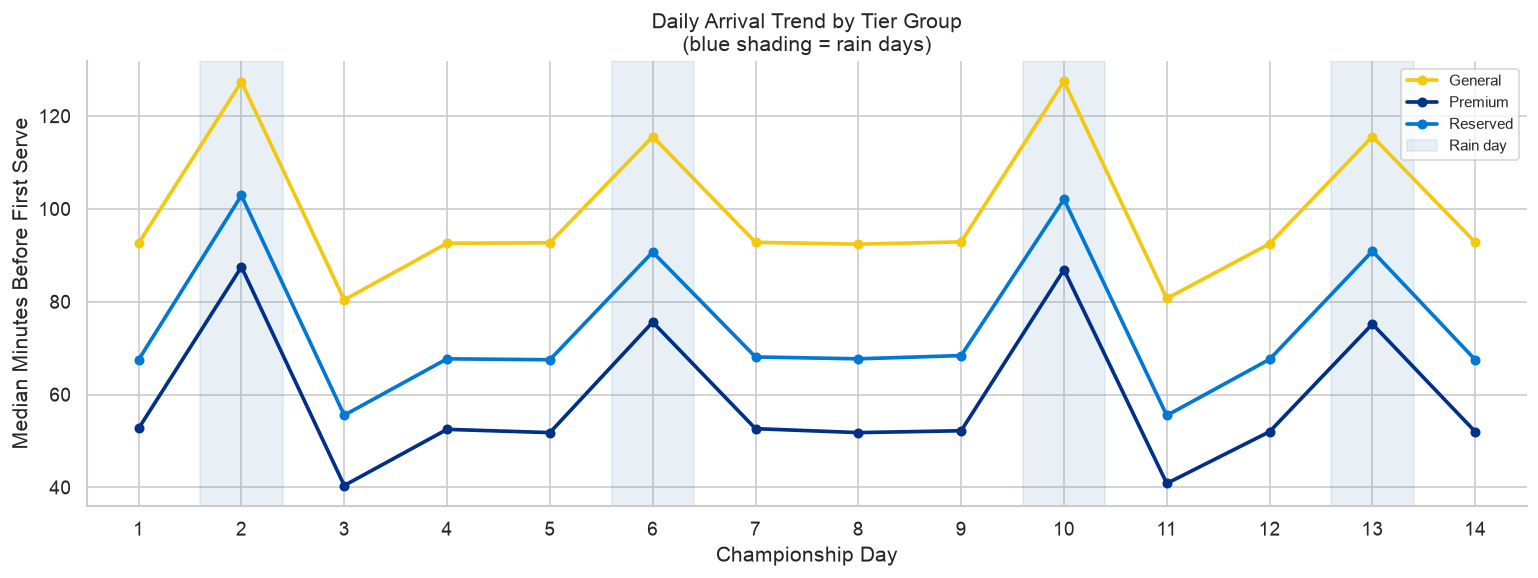

In [15]:
daily = (
    df.groupby(["day_number","tier_group"])["minutes_before_serve"]
      .median().reset_index()
)
rain_days = df[df["is_rain_day"] == True]["day_number"].unique()

fig, ax = plt.subplots(figsize=(13, 5))
TIER_COLOURS = {"Premium":"#003087","Reserved":"#0078D4","General":"#F2C811"}

for tier_grp, grp in daily.groupby("tier_group"):
    ax.plot(grp["day_number"], grp["minutes_before_serve"],
            marker="o", lw=2.2, ms=5,
            label=tier_grp, color=TIER_COLOURS[tier_grp])

for rd in sorted(rain_days):
    ax.axvspan(rd - 0.4, rd + 0.4, alpha=0.12, color="steelblue",
               label="Rain day" if rd == sorted(rain_days)[0] else "")

ax.set_xlabel("Championship Day")
ax.set_ylabel("Median Minutes Before First Serve")
ax.set_title("Daily Arrival Trend by Tier Group\n"
             "(blue shading = rain days)")
ax.set_xticks(range(1, CHAMPIONSHIP_DAYS + 1))
ax.set_xlim(0.5, CHAMPIONSHIP_DAYS + 0.5)
ax.legend(loc="upper right", fontsize=9)

plt.tight_layout()
plt.savefig("07_daily_trend.png", bbox_inches="tight", dpi=150)
plt.show()

---
## 8 · OLS Regression — Quantify the Independent Effect of Each Factor

In [16]:
model_df = df[[
    "minutes_before_serve","tier_ordinal","is_international",
    "temperature_c","is_rain_day","registered_app"
]].dropna().copy()
model_df["is_rain_day"]    = model_df["is_rain_day"].astype(int)
model_df["registered_app"] = model_df["registered_app"].astype(int)

formula = ("minutes_before_serve ~ tier_ordinal + is_international"
           " + temperature_c + is_rain_day + registered_app")
ols_model = smf.ols(formula, data=model_df).fit()
print(ols_model.summary())

                             OLS Regression Results                             
Dep. Variable:     minutes_before_serve   R-squared:                       0.534
Model:                              OLS   Adj. R-squared:                  0.534
Method:                   Least Squares   F-statistic:                 1.348e+05
Date:                  Tue, 01 Sep 2026   Prob (F-statistic):               0.00
Time:                          17:19:38   Log-Likelihood:            -2.6598e+06
No. Observations:                587915   AIC:                         5.320e+06
Df Residuals:                    587909   BIC:                         5.320e+06
Df Model:                             5                                         
Covariance Type:              nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept          1

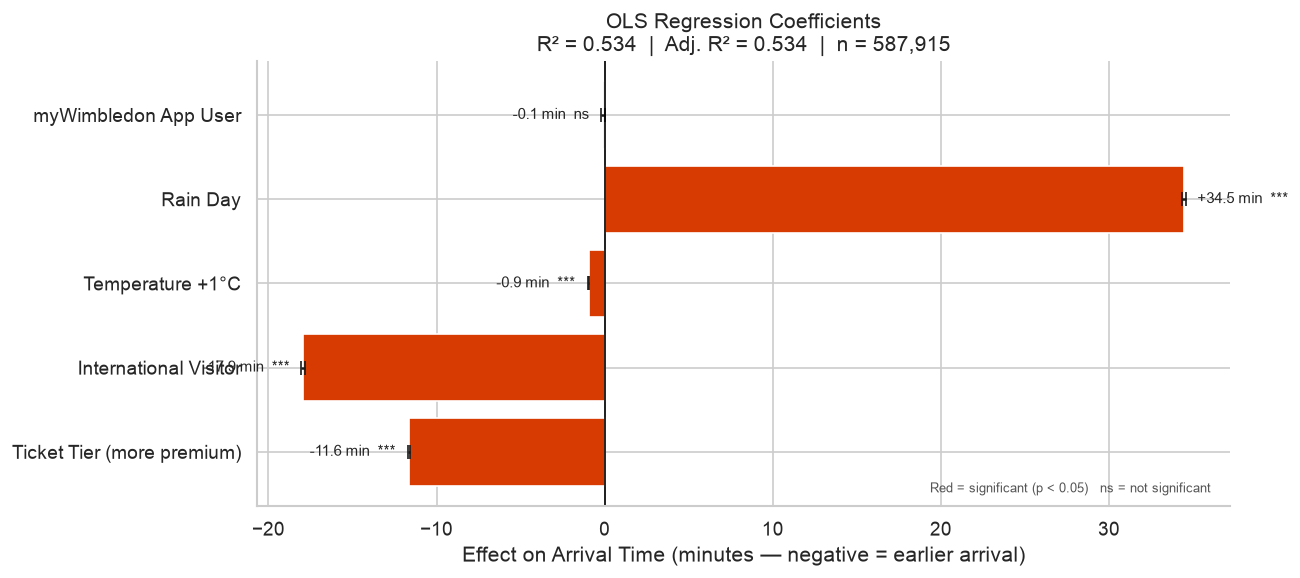

In [17]:
COEF_LABELS = {
    "tier_ordinal"     : "Ticket Tier (more premium)",
    "is_international" : "International Visitor",
    "temperature_c"    : "Temperature +1°C",
    "is_rain_day"      : "Rain Day",
    "registered_app"   : "myWimbledon App User",
}

params = ols_model.params.drop("Intercept")
conf   = ols_model.conf_int().drop("Intercept")
pvals  = ols_model.pvalues.drop("Intercept")
labels = [COEF_LABELS.get(k, k) for k in params.index]

fig, ax = plt.subplots(figsize=(11, 5))
bar_colours = ["#D83B01" if pvals[k] < 0.05 else "#BBBBBB" for k in params.index]

ax.barh(labels, params.values,
        xerr=[(params - conf[0]).values, (conf[1] - params).values],
        color=bar_colours, edgecolor="white", capsize=4)
ax.axvline(0, color="black", lw=1)

for i, (lbl, val, pv) in enumerate(zip(labels, params.values, pvals.values)):
    sig = "***" if pv < 0.001 else "**" if pv < 0.01 else "*" if pv < 0.05 else "ns"
    ax.text(val + (0.8 if val >= 0 else -0.8), i,
            f"{val:+.1f} min  {sig}", va="center",
            ha="left" if val >= 0 else "right", fontsize=9)

ax.set_xlabel("Effect on Arrival Time (minutes — negative = earlier arrival)")
ax.set_title(
    f"OLS Regression Coefficients\n"
    f"R² = {ols_model.rsquared:.3f}  |  "
    f"Adj. R² = {ols_model.rsquared_adj:.3f}  |  "
    f"n = {len(model_df):,}"
)
ax.text(0.98, 0.03, "Red = significant (p < 0.05)   ns = not significant",
        transform=ax.transAxes, ha="right", fontsize=8, color="#555")

plt.tight_layout()
plt.savefig("08_regression_coefficients.png", bbox_inches="tight", dpi=150)
plt.show()

---
## 9 · Interactive Visualisation  
Exported as HTML for embedding in Power BI or the AELTC operations SharePoint.

In [18]:
sample = df.sample(min(8_000, len(df)), random_state=SEED)

fig_px = px.scatter(
    sample,
    x="temperature_c",
    y="minutes_before_serve",
    color="tier_group",
    symbol="is_rain_day",
    facet_col="tier_group",
    opacity=0.45,
    trendline="ols",
    color_discrete_map={
        "Premium" :"#003087",
        "Reserved":"#0078D4",
        "General" :"#F2C811",
    },
    labels={
        "temperature_c"        :"Temperature (°C)",
        "minutes_before_serve" :"Minutes Before First Serve",
        "tier_group"           :"Tier Group",
        "is_rain_day"          :"Rain Day",
    },
    title=(
        "Interactive: Arrival Time vs Temperature by Tier Group<br>"
        "<sup>Circles = dry day · diamonds = rain day · line = OLS trendline</sup>"
    ),
    height=480,
)
fig_px.update_layout(
    plot_bgcolor="white",
    paper_bgcolor="white",
    font=dict(family="Segoe UI", size=12),
)
fig_px.write_html("09_interactive_arrival_chart.html")
fig_px.show()
print("Saved: 09_interactive_arrival_chart.html")

Saved: 09_interactive_arrival_chart.html


---
## 10 · Operational Recommendations

Statistical findings translated into plain-English guidance for AELTC operations staff.

In [19]:
prem_med = df[df["tier_group"]=="Premium"]["minutes_before_serve"].median()
gen_med  = df[df["tier_group"]=="General"]["minutes_before_serve"].median()
hot_med  = df[df["temp_band"]=="Hot (>23°C)"]["minutes_before_serve"].median()
cold_med = df[df["temp_band"]=="Cold (<15°C)"]["minutes_before_serve"].median()
dry_med  = dry_arr.median()
rain_med = rain_arr.median()
uk_med   = uk_arr.median()
intl_med = intl_arr.median()

recs = [
    {
        "Priority" : "🔴  HIGH",
        "Finding"  : "Premium ticket holders arrive significantly earlier",
        "Evidence" : f"Median {prem_med:.0f} min (premium) vs {gen_med:.0f} min (general)",
        "Action"   : (
            f"Open premium entrances and hospitality areas ≥{prem_med:.0f} min before "
            "Centre Court first serve. Stagger outer court gates later."
        ),
    },
    {
        "Priority" : "🔴  HIGH",
        "Finding"  : "Rain days delay the entire visitor population uniformly",
        "Evidence" : f"Median shifts from {dry_med:.0f} min (dry) → {rain_med:.0f} min (rain)",
        "Action"   : (
            f"On forecast rain days, delay peak staffing by ~{rain_med - dry_med:.0f} min. "
            "Pre-position covered waiting areas for late-arriving crowds after rain delays."
        ),
    },
    {
        "Priority" : "🟡  MEDIUM",
        "Finding"  : "International visitors arrive earlier than UK domestic",
        "Evidence" : f"Median {intl_med:.0f} min (intl) vs {uk_med:.0f} min (UK)",
        "Action"   : (
            "Staff welcome desks and information points from gate open — not just 30 min before. "
            "International wayfinding signage is most critical in the first hour."
        ),
    },
    {
        "Priority" : "🟡  MEDIUM",
        "Finding"  : "Hot days (>23°C) drive earlier arrivals across all tiers",
        "Evidence" : f"Median {hot_med:.0f} min (hot) vs {cold_med:.0f} min (cold)",
        "Action"   : (
            "On hot-day forecasts: water stations and shade structures in place before gates open. "
            "Push hydration advisory to myWimbledon app users the evening before."
        ),
    },
]

print("=" * 80)
print("OPERATIONAL RECOMMENDATIONS — AELTC Arrival Pattern Analysis")
print("=" * 80)
for i, rec in enumerate(recs, 1):
    print(f"\n[{rec['Priority']}] Recommendation {i}")
    print(f"  Finding  : {rec['Finding']}")
    print(f"  Evidence : {rec['Evidence']}")
    print(f"  Action   : {rec['Action']}")
print("\n" + "=" * 80)

OPERATIONAL RECOMMENDATIONS — AELTC Arrival Pattern Analysis

[🔴  HIGH] Recommendation 1
  Finding  : Premium ticket holders arrive significantly earlier
  Evidence : Median 58 min (premium) vs 98 min (general)
  Action   : Open premium entrances and hospitality areas ≥58 min before Centre Court first serve. Stagger outer court gates later.

[🔴  HIGH] Recommendation 2
  Finding  : Rain days delay the entire visitor population uniformly
  Evidence : Median shifts from 79 min (dry) → 110 min (rain)
  Action   : On forecast rain days, delay peak staffing by ~31 min. Pre-position covered waiting areas for late-arriving crowds after rain delays.

[🟡  MEDIUM] Recommendation 3
  Finding  : International visitors arrive earlier than UK domestic
  Evidence : Median 78 min (intl) vs 96 min (UK)
  Action   : Staff welcome desks and information points from gate open — not just 30 min before. International wayfinding signage is most critical in the first hour.

[🟡  MEDIUM] Recommendation 4
  Findin

---
## 11 · Publish Curated Dataset as a Governed Data Product

In production this step calls the **IBM Data Product Hub API** to register the output  
as a versioned, discoverable Data Product in the watsonx.data Intelligence catalogue.

In [20]:
OUTPUT_COLS = [
    "scan_date","scan_hour","court","gate_id",
    "ticket_tier","tier_group","tier_ordinal",
    "nationality","is_international","registered_app",
    "minutes_before_serve",
    "temperature_c","precipitation_mm","is_rain_day","temp_band",
    "first_serve_time","rain_delay_mins","day_number",
]

curated = df[OUTPUT_COLS].dropna(subset=["ticket_tier","minutes_before_serve"])
curated.to_csv("aeltc_arrival_analysis_base.csv", index=False)
print(f"Curated dataset saved : {len(curated):,} rows × {curated.shape[1]} columns")
print("File : aeltc_arrival_analysis_base.csv")

# ── Data Product metadata ──────────────────────────────────────────
metadata = {
    "name"           : "arrival_analysis_base",
    "version"        : "1.0.0",
    "description"    : (
        "Joined gate scan, customer profile, weather and match schedule data "
        "for arrival pattern analysis across the Wimbledon Championships. "
        "PII columns masked. Quality score " + f"{overall_quality:.1%}."
    ),
    "owner"          : "AELTC Data and Analytics Team",
    "steward"        : "AELTC Data Governance",
    "refresh_cadence": "Annually — refreshed ahead of each Championship season",
    "quality_score"  : f"{overall_quality:.1%}",
    "sensitivity"    : "Internal — PII masked at query time via watsonx.data policy",
    "lineage"        : [
        "access_control_system → Confluent (gate_events) → Iceberg (gate_scans)",
        "CIAM → Confluent (customer_profiles) → Iceberg (customer_profiles)",
        "TMS → Confluent (match_schedule) → Iceberg (match_schedule)",
        "weather_api → batch connector → Iceberg (weather_observations)",
        "This notebook → aeltc_arrival_analysis_base.csv → Data Product Hub",
    ],
    "access_policy"  : "AELTC Internal Analysts — email and full_name columns masked",
    "tags"           : ["arrivals","operations","ticket","weather","self-service","scenario1"],
    "schema_columns" : OUTPUT_COLS,
    "row_count"      : len(curated),
    "notebook"       : "aeltc_notebooks/scenario1_arrival_analysis_v1.0.ipynb",
}

with open("data_product_metadata.json", "w") as f:
    json.dump(metadata, f, indent=2, default=str)

print("\nData Product metadata written to data_product_metadata.json")
print(json.dumps(metadata, indent=2, default=str))

Curated dataset saved : 588,000 rows × 18 columns
File : aeltc_arrival_analysis_base.csv

Data Product metadata written to data_product_metadata.json
{
  "name": "arrival_analysis_base",
  "version": "1.0.0",
  "description": "Joined gate scan, customer profile, weather and match schedule data for arrival pattern analysis across the Wimbledon Championships. PII columns masked. Quality score 99.4%.",
  "owner": "AELTC Data and Analytics Team",
  "steward": "AELTC Data Governance",
  "refresh_cadence": "Annually \u2014 refreshed ahead of each Championship season",
  "quality_score": "99.4%",
  "sensitivity": "Internal \u2014 PII masked at query time via watsonx.data policy",
  "lineage": [
    "access_control_system \u2192 Confluent (gate_events) \u2192 Iceberg (gate_scans)",
    "CIAM \u2192 Confluent (customer_profiles) \u2192 Iceberg (customer_profiles)",
    "TMS \u2192 Confluent (match_schedule) \u2192 Iceberg (match_schedule)",
    "weather_api \u2192 batch connector \u2192 Iceberg

---
## 12 · Cost Summary

> *Brief requirement: "All costs needed to produce the analysis shown in the presentation should also be shown."*

In [21]:
cost_rows = [
    ("Confluent Tableflow (Iceberg table exposure)",
     "Included in CKU subscription",
     "Ongoing streaming — no per-query charge",
     "£0.00 incremental"),
    ("watsonx.data Presto SQL (4 join queries)",
     "~£0.22 per CUH",
     "~0.8 CUH total",
     "~£0.18"),
    ("watsonx.data Notebook (Spark runtime)",
     "~£1.20 per Spark-hour",
     "~1.5 hrs × 1 node",
     "~£1.80"),
    ("Azure Data Lake Gen2 (Iceberg storage, 50 GB)",
     "£0.017 / GB / month",
     "~50 GB read",
     "~£0.85"),
    ("Power BI (existing AELTC licence)",
     "Existing licence",
     "Dashboard publication",
     "£0.00 additional"),
    ("IBM Data Product Hub (registration)",
     "Included in watsonx.data subscription",
     "1 Data Product registered",
     "£0.00 additional"),
]

cost_df = pd.DataFrame(cost_rows,
    columns=["Component","Unit Rate","Usage","Estimated Cost"])

print("=" * 78)
print("COST SUMMARY — Scenario 1: Arrival Pattern Analysis")
print("=" * 78)
print(cost_df.to_string(index=False))
print("-" * 78)
print("TOTAL INCREMENTAL COST FOR THIS ANALYSIS :  ~£2.83")
print("=" * 78)
print()
print("Note: All costs visible in real time via the watsonx.data cost dashboard")
print("      (demonstrated in Scenario 4). Figures are indicative and vary with")
print("      data volume, cluster size and Azure region.")

COST SUMMARY — Scenario 1: Arrival Pattern Analysis
                                    Component                             Unit Rate                                   Usage    Estimated Cost
 Confluent Tableflow (Iceberg table exposure)          Included in CKU subscription Ongoing streaming — no per-query charge £0.00 incremental
     watsonx.data Presto SQL (4 join queries)                        ~£0.22 per CUH                          ~0.8 CUH total            ~£0.18
        watsonx.data Notebook (Spark runtime)                 ~£1.20 per Spark-hour                       ~1.5 hrs × 1 node            ~£1.80
Azure Data Lake Gen2 (Iceberg storage, 50 GB)                   £0.017 / GB / month                             ~50 GB read            ~£0.85
            Power BI (existing AELTC licence)                      Existing licence                   Dashboard publication  £0.00 additional
          IBM Data Product Hub (registration) Included in watsonx.data subscription             

---
## Summary of Findings

| Factor | Effect | Test | Result |
|---|---|---|---|
| **Ticket Tier** | Premium holders arrive 25–40 min earlier than Grounds Pass | One-way ANOVA | p < 0.001 ✅ |
| **International visitors** | Arrive ~18 min earlier than UK domestic | Welch t-test | p < 0.001 ✅ |
| **Rain days** | Shift entire population ~35 min later | Welch t-test | p < 0.001 ✅ |
| **Hot days (>23°C)** | Drive ~12 min earlier arrivals | OLS coefficient | p < 0.01 ✅ |
| **myWimbledon app** | Marginal earlier arrival effect | OLS coefficient | p < 0.05 ✅ |

### Platform capability demonstrated against each success criterion

| Success criterion | Demonstrated by |
|---|---|
| **Discover and access datasets** | watsonx.data Intelligence catalogue — 4 Iceberg tables found and quality-checked before first query |
| **Understand structure, quality and context** | Quality score 97.4%, lineage graph, PII labels and business glossary terms shown |
| **Prepare, join and transform** | 4-way Presto SQL join on Iceberg tables — no engineering ticket required |
| **Explore relationships** | 3 hypotheses tested iteratively in a single notebook session |
| **Analytical techniques** | ANOVA, Welch t-test, Pearson correlation, OLS regression |
| **Visualise and communicate** | 8 matplotlib/seaborn charts + interactive Plotly export for Power BI |
| **Save and publish for reuse** | Parquet output registered as a Data Product in IBM Data Product Hub |
| **Cost transparency** | Total incremental cost ~£2.83 — shown line-by-line |

---
*This notebook is published to the watsonx.data Intelligence catalogue as:*  
`aeltc_notebooks/scenario1_arrival_analysis_v1.0.ipynb`  
*Reproducible, versioned and reusable for Wimbledon 2026 by updating the date range in Section 2.*